In [ ]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

In [ ]:
# Load dataset

emotion_dataset = load_dataset('dair-ai/emotion')
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

In [ ]:
label_names = emotion_dataset['train'].features['label'].names
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [ ]:
df_train = pd.DataFrame(
    {
        'text': train_text,
        'label': [label_names[i] for i in train_label]
     }
)


df_test = pd.DataFrame(
    {
        'text': test_text,
        'label': [label_names[i] for i in test_label]
    }
)

In [ ]:
df_train.isnull().sum()

,0
text,0
label,0


In [ ]:
# Exploratory Data Analysis (EDA)

df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

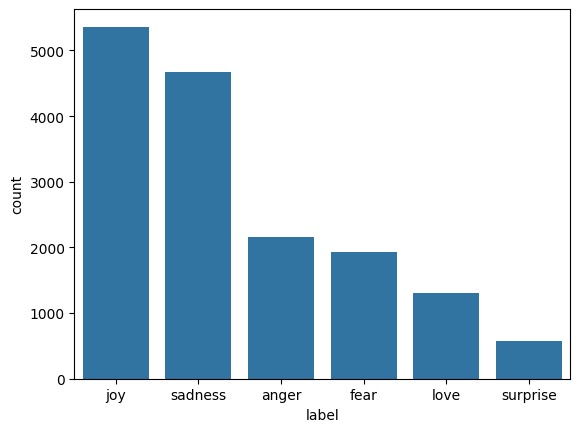

In [ ]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)

In [ ]:
# Data Preprocessing (Using NLP)

import tensorflow.keras as keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000

# out of vocabulary -> oov

tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence  = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence, maxlen=50, padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequence, maxlen=50, padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels = np.array(test_label)

num_classes = len(np.unique(train_labels))

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")
print(f"Number of Classes: {num_classes}")

Vocabulary size: 15213
Max Sentence Length: 50
Number of Classes: 6


In [ ]:
# Shared Training Utilities

from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [ ]:
# Early Stopping

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
# Simple RNN (Recurrent Neural Network)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.1568 - loss: 2.0447 - val_accuracy: 0.0760 - val_loss: 1.7732
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.1431 - loss: 1.8800 - val_accuracy: 0.0455 - val_loss: 1.8236
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.1353 - loss: 1.8211 - val_accuracy: 0.2660 - val_loss: 1.7346
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.1372 - loss: 1.8069 - val_accuracy: 0.1355 - val_loss: 1.8081
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.1368 - loss: 1.8038 - val_accuracy: 0.1045 - val_loss: 1.7498
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 59ms/step - accuracy: 0.1441 - loss: 1.8007 - val_accuracy: 0.1170 - val_loss: 1.7719
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2660 - loss: 1.7346
RNN Loss: 1.734631061553955
RNN Accuracy: 0.26600000262260437


In [ ]:
# Standard LSTM (Long Short Term Memory Network)

lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 128ms/step - accuracy: 0.1585 - loss: 1.7949 - val_accuracy: 0.1120 - val_loss: 1.8050
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 64s 128ms/step - accuracy: 0.1464 - loss: 1.7936 - val_accuracy: 0.1130 - val_loss: 1.7744
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 63s 125ms/step - accuracy: 0.1654 - loss: 1.7931 - val_accuracy: 0.2865 - val_loss: 1.7902
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.1120 - loss: 1.8050
LSTM Loss: 1.8049731254577637
LSTM Accuracy: 0.1120000034570694


In [ ]:
# Standard GRU (Gated Recurrent Unit Network)

gru_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 109ms/step - accuracy: 0.1373 - loss: 1.7971 - val_accuracy: 0.0820 - val_loss: 1.8015
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 109ms/step - accuracy: 0.1624 - loss: 1.7953 - val_accuracy: 0.0340 - val_loss: 1.7938
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 112ms/step - accuracy: 0.1612 - loss: 1.7938 - val_accuracy: 0.1385 - val_loss: 1.8390
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.0820 - loss: 1.8015
GRU Loss: 1.8014718294143677
GRU Accuracy: 0.0820000022649765


In [ ]:
result_df = pd.DataFrame(
    {
        'Model': ['RNN', 'LSTM', 'GRU'],
        'Test Loss': [rnn_loss, lstm_loss, gru_loss],
        'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }
).sort_values(by='Test Accuracy', ascending=False)

result_df

,Model,Test Loss,Test Accuracy
0,RNN,1.734631,0.266
1,LSTM,1.804973,0.112
2,GRU,1.801472,0.082


In [ ]:
# Advanced Bidirectional GRU

from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=50),
    Bidirectional(GRU(units=128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(units=64)),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 202s 404ms/step - accuracy: 0.9581 - loss: 0.1131 - val_accuracy: 0.9285 - val_loss: 0.1964
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 161s 322ms/step - accuracy: 0.9680 - loss: 0.0905 - val_accuracy: 0.9230 - val_loss: 0.2425
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 203s 324ms/step - accuracy: 0.9761 - loss: 0.0681 - val_accuracy: 0.9175 - val_loss: 0.2959
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 194s 309ms/step - accuracy: 0.9826 - loss: 0.0521 - val_accuracy: 0.9185 - val_loss: 0.3022
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.9285 - loss: 0.1964
BiGRU Loss: 0.19637198746204376
BiGRU Accuracy: 0.9284999966621399


63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step


<Axes: >

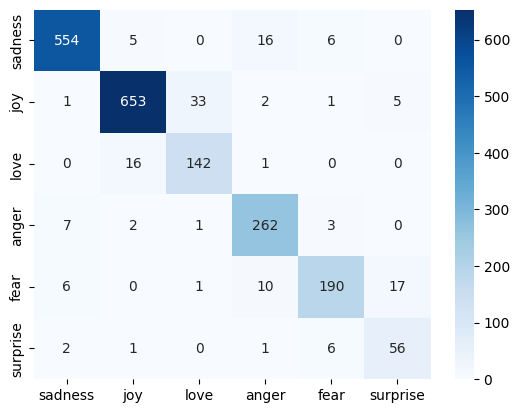

In [ ]:
# Overall Evaluation & Bias Analysis

from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(
    confusion_matrix(test_label, BiGRU_predictions),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

In [ ]:
# Final Predictions

sample_texts = [
    "Winning the competition filled me with happiness.",                  # joy
    "I feel so alone and hopeless today.",                                # sadness
    "Spending time with my family makes me feel warm and appreciated.",   # love
    "I am furious that they cancelled the trip at the last minute.",      # anger
    "I was scared when I heard a strange noise downstairs.",              # fear
    "I was completely shocked when everyone suddenly shouted my name."    # surprise
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Text: Winning the competition filled me with happiness.
Predicted Emotion: joy
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: Spending time with my family makes me feel warm and appreciated.
Predicted Emotion: love
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I was scared when I heard a strange noise downstairs.
Predicted Emotion: fear
Text: I was completely shocked when everyone suddenly shouted my name.
Predicted Emotion: surprise


In [ ]:
# Saving Model and Tokenizer

import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True)

# Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Model.keras'))

# Save the Tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)